loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package chd...


    loading package oc...
  loading solution package gwf_model...


C:\Users\u4eeevmq\AppData\Local\Temp\ipykernel_6828\4199727153.py:52: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  domain_polygon = gdf.unary_union  # single multipolygon


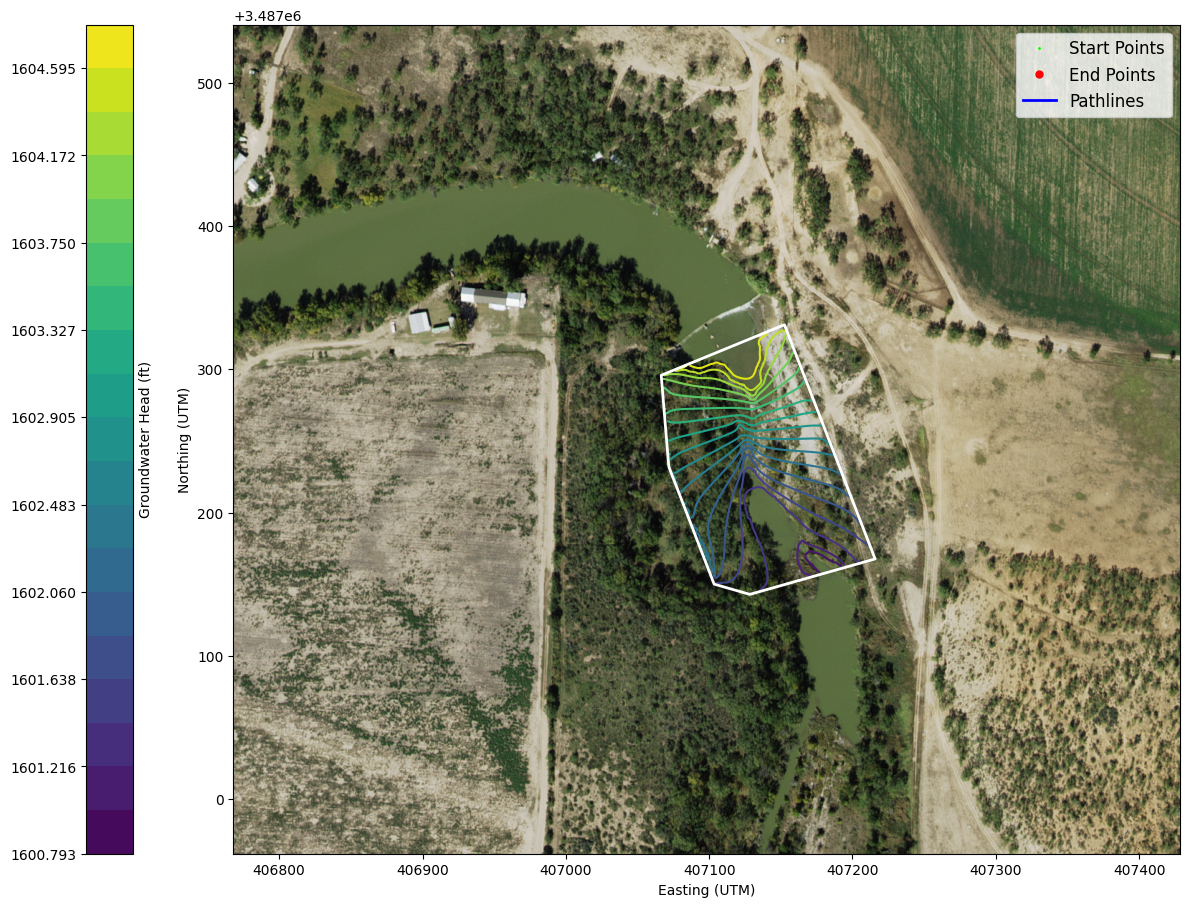

In [1]:
import flopy
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely.geometry import Point

# --- Step 1: Load MODFLOW 6 Simulation and GWF Model ---
sim_name = "Hyporheic_Project"
sim_path = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\gwf_workspace"
exe_name = r"C:\Users\u4eeevmq\Documents\Python\Flo_Py\flopy\modflowExe\mf6.exe"

gwfsim = flopy.mf6.MFSimulation.load(sim_name=sim_name, sim_ws=sim_path, exe_name=exe_name)
gwf = gwfsim.get_model(gwfsim.model_names[0])

# --- Step 2: Load Head Data ---
head_file = rf"{sim_path}\{gwf.name}.hds"
head_obj = flopy.utils.HeadFile(head_file)
head = head_obj.get_data(totim=head_obj.get_times()[-1])  # shape: (nlay, nrow, ncol)

# --- Step 3: Get idomain for masking ---
dis = gwf.get_package("DIS")
idomain = dis.idomain.array  # shape: (nlay, nrow, ncol)

# --- Use your variables ---
layer_to_plot = 1
head_layer = head[layer_to_plot, :, :]
idomain_layer = idomain[layer_to_plot, :, :]
head_layer_masked = np.ma.masked_where(idomain_layer == 0, head_layer)

# --- Satellite image ---
sat_image_path = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\CH00365\GMS\HighResOrtho\HighResOrtho_23Oct2014_Clip.tif"
with rasterio.open(sat_image_path) as src:
    if src.count >= 3:
        img = np.dstack([src.read(i) for i in [1,2,3]])
        img = img.astype(float)
        for i in range(3):
            band = img[:,:,i]
            img[:,:,i] = (band - band.min()) / (band.max() - band.min())
    else:
        img = src.read(1)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    img_crs = src.crs

# --- Load groundwater domain shapefile ---
shp_path = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\CH00365\InputShapefiles\GWDomain.shp"
gdf = gpd.read_file(shp_path)
if gdf.crs != img_crs:
    gdf = gdf.to_crs(img_crs)
domain_polygon = gdf.unary_union  # single multipolygon

# --- Get MODFLOW grid cell centers ---
nrow, ncol = head_layer.shape
x = np.linspace(extent[0], extent[1], ncol)
y = np.linspace(extent[2], extent[3], nrow)
Xc, Yc = np.meshgrid(x, y)

# --- Clip head data to shapefile polygon ---
mask_shape = np.zeros_like(head_layer_masked, dtype=bool)
for i in range(nrow):
    for j in range(ncol):
        pt = Point(Xc[i, j], Yc[i, j])
        mask_shape[i, j] = domain_polygon.contains(pt)
head_layer_clipped = np.ma.masked_where(~mask_shape, head_layer_masked)

# Set levels for contours
levels = np.linspace(np.nanmin(head_layer_clipped), np.nanmax(head_layer_clipped), 20)

# --- Load particle points GeoDataFrame ---
points_shp = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\Hyporheic_output\Forward_hyporheic_points.shp"
gdf_points = gpd.read_file(points_shp)
if gdf_points.crs != img_crs:
    gdf_points = gdf_points.to_crs(img_crs)

# --- Get start and end points by particleid ---
# Sort by time/residence time if needed, then group
gdf_points_sorted = gdf_points.sort_values(['particleid', 'res_time'])
start_points = gdf_points_sorted.groupby('particleid').first()
end_points = gdf_points_sorted.groupby('particleid').last()

# --- Load pathlines GeoDataFrame ---
lines_shp = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\Hyporheic_output\Forward_hyporheic_pathlines_HECRAS_CRS.shp"
gdf_lines = gpd.read_file(lines_shp)
if gdf_lines.crs != img_crs:
    gdf_lines = gdf_lines.to_crs(img_crs)
    
import matplotlib.lines as mlines

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(img, extent=extent, origin='upper', zorder=1)

# Contour plots
contourf = ax.contourf(Xc, Yc, head_layer_clipped, levels=levels, cmap='viridis', alpha=1.0, zorder=0)
contour = ax.contour(Xc, Yc, head_layer_clipped, levels=levels, cmap='viridis', zorder=2)

# Plot start points (blue), end points (red)
#start_points.plot(ax=ax, marker='o', color='lime', markersize=5, label='_nolegend_', zorder=5)
#end_points.plot(ax=ax, marker='o', color='red', markersize=5, label='_nolegend_', zorder=4)

# Plot pathlines (lines GeoDataFrame)
#gdf_lines.plot(ax=ax, color='blue', linewidth=0.5, label='_nolegend_', zorder=3)

# Plot groundwater domain boundary in white
gdf.boundary.plot(ax=ax, edgecolor='white', linewidth=2, zorder=6)

# Custom legend handles
start_handle = mlines.Line2D([], [], color='lime', marker='o', linestyle='None', markersize=1, label='Start Points')
end_handle = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=5, label='End Points')
line_handle = mlines.Line2D([], [], color='blue', linewidth=2, label='Pathlines')

# Add legend in top right
ax.legend(handles=[start_handle, end_handle, line_handle], loc='upper right', fontsize=12, frameon=True)

# Colorbar on the left
divider = make_axes_locatable(ax)
cax = divider.append_axes("left", size="5%", pad=1.0)
cb = fig.colorbar(contourf, cax=cax)
cax.yaxis.set_ticks_position('left')
cb.set_label('Groundwater Head (ft)')

plt.title('')
ax.set_xlabel('Easting (UTM)')
ax.set_ylabel('Northing (UTM)')
plt.tight_layout()
plt.show()

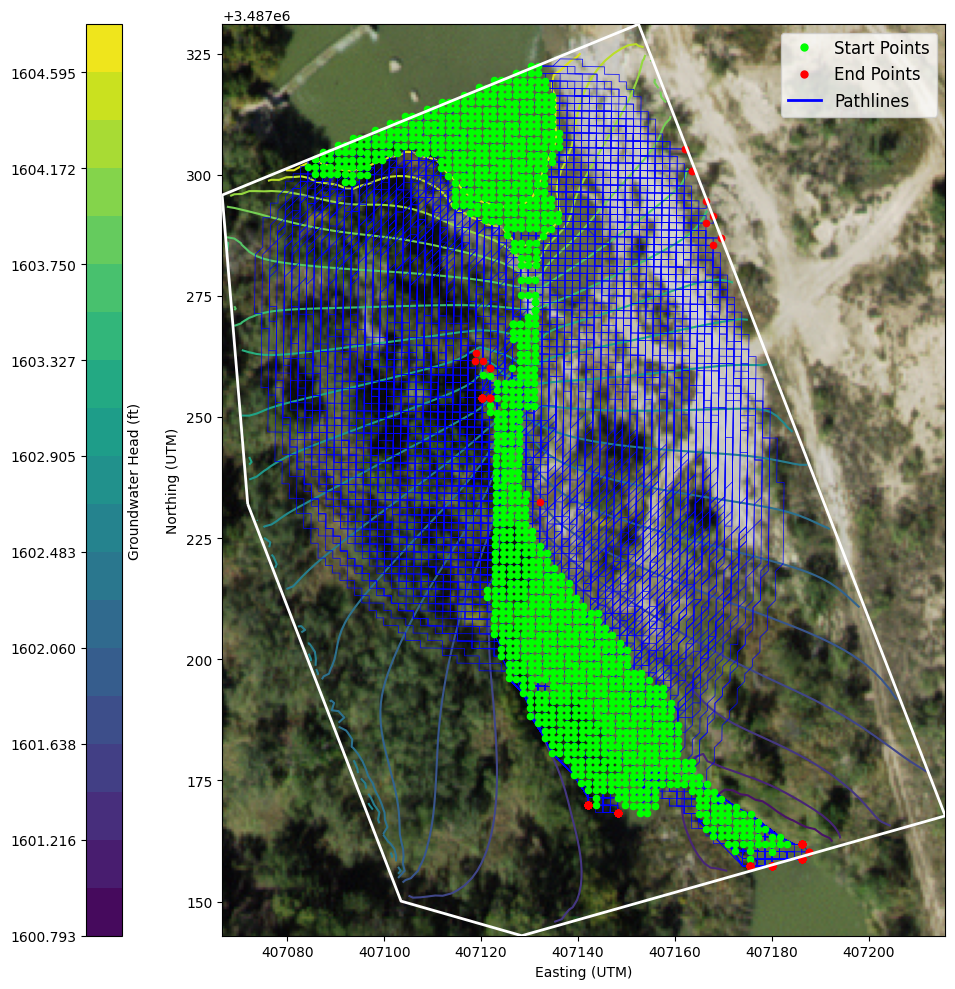

In [2]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))

# Show background image
ax.imshow(img, extent=extent, origin='upper', zorder=1)

# Contour plots
contourf = ax.contourf(Xc, Yc, head_layer_clipped, levels=levels, cmap='viridis', alpha=1.0, zorder=0)
contour = ax.contour(Xc, Yc, head_layer_clipped, levels=levels, cmap='viridis', zorder=2)

# Plot pathlines (lines GeoDataFrame)
gdf_lines.plot(ax=ax, color='blue', linewidth=0.5, label='_nolegend_', zorder=3)

# Plot points with scatter for visibility
ax.scatter(start_points.geometry.x, start_points.geometry.y, color='lime', s=20, label='Start Points', zorder=5)
ax.scatter(end_points.geometry.x, end_points.geometry.y, color='red', s=20, label='End Points', zorder=6)

# Plot groundwater domain boundary in white
gdf.boundary.plot(ax=ax, edgecolor='white', linewidth=2, zorder=6)

# Crop to groundwater domain boundary extent
xmin, ymin, xmax, ymax = gdf.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Custom legend handles
start_handle = mlines.Line2D([], [], color='lime', marker='o', linestyle='None', markersize=5, label='Start Points')
end_handle = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=5, label='End Points')
line_handle = mlines.Line2D([], [], color='blue', linewidth=2, label='Pathlines')

# Add legend in top right
ax.legend(handles=[start_handle, end_handle, line_handle], loc='upper right', fontsize=12, frameon=True)

# Colorbar on the left
divider = make_axes_locatable(ax)
cax = divider.append_axes("left", size="5%", pad=1.0)
cb = fig.colorbar(contourf, cax=cax)
cax.yaxis.set_ticks_position('left')
cb.set_label('Groundwater Head (ft)')

plt.title('')
ax.set_xlabel('Easting (UTM)')
ax.set_ylabel('Northing (UTM)')
plt.tight_layout()
plt.show()

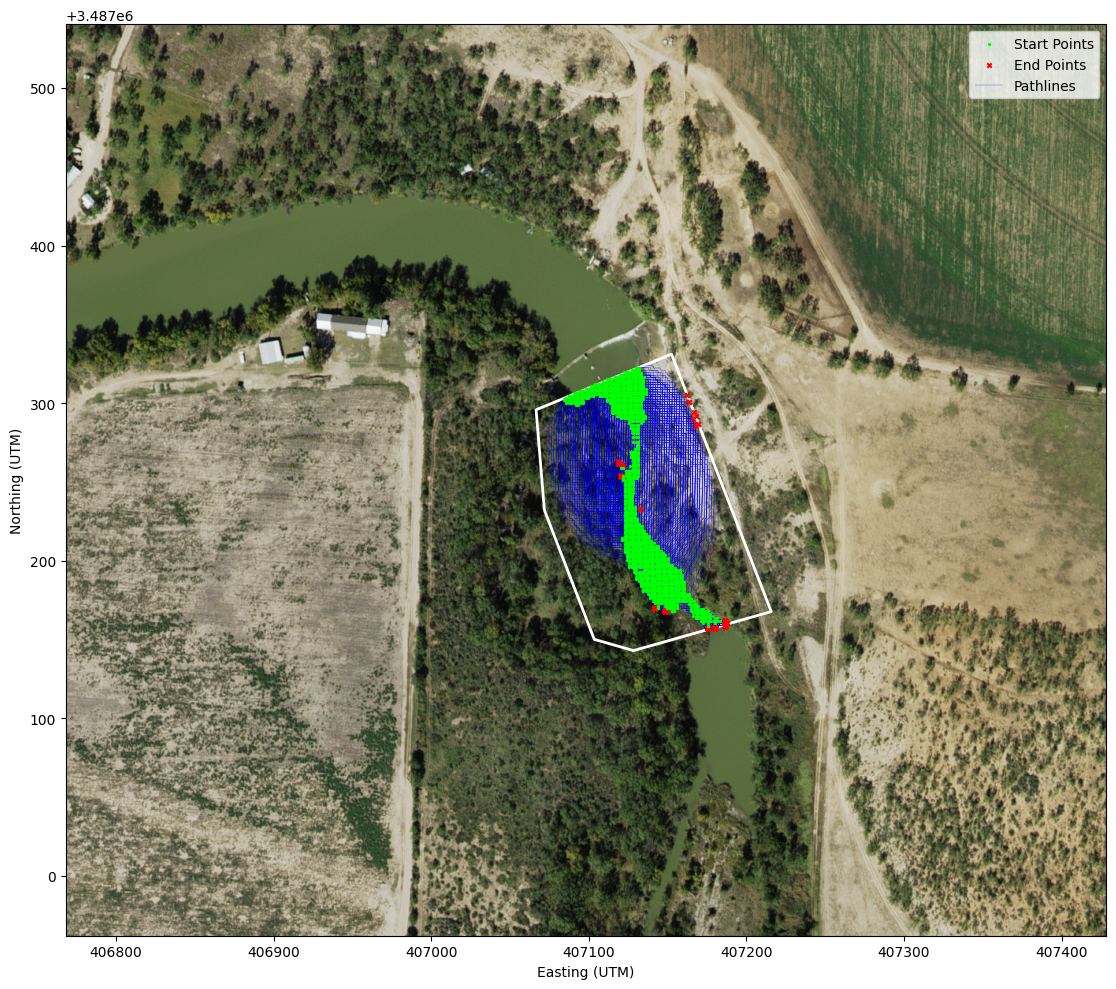

In [3]:
import pandas as pd

# --- Load particle points GeoDataFrame ---
points_shp = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\Hyporheic_output\Forward_hyporheic_points_HECRAS_CRS.shp"
gdf_points = gpd.read_file(points_shp)
if gdf_points.crs != img_crs:
    gdf_points = gdf_points.to_crs(img_crs)

# --- Get start and end points by particleid ---
# Sort by time/residence time if needed, then group
gdf_points_sorted = gdf_points.sort_values(['particleid', 'res_time'])
start_points = gdf_points_sorted.groupby('particleid').first()
end_points = gdf_points_sorted.groupby('particleid').last()

# --- Load pathlines GeoDataFrame ---
lines_shp = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\Hyporheic_output\Forward_hyporheic_pathlines_HECRAS_CRS.shp"
gdf_lines = gpd.read_file(lines_shp)
if gdf_lines.crs != img_crs:
    gdf_lines = gdf_lines.to_crs(img_crs)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(img, extent=extent, origin='upper')
gdf.boundary.plot(ax=ax, edgecolor='white', linewidth=2, zorder=2)

# Plot start points (blue), end points (red)
start_points.plot(ax=ax, marker='o', color='lime', markersize=2, label='Start Points', zorder=5)
end_points.plot(ax=ax, marker='x', color='red', markersize=10, label='End Points', zorder=4)

# Plot pathlines (lines GeoDataFrame)
gdf_lines.plot(ax=ax, color='blue', linewidth=0.2, label='Pathlines', zorder=3)

plt.legend()
plt.xlabel('Easting (UTM)')
plt.ylabel('Northing (UTM)')
plt.title('')
plt.tight_layout()
plt.show()

In [4]:
# --- Use real-world coordinates ---
delr = dis.delr.array  # shape: (ncol,)
delc = dis.delc.array  # shape: (nrow,)

x = np.cumsum(np.insert(delr, 0, 0))[:-1]  # left edge of each column
y = np.cumsum(np.insert(delc, 0, 0))[:-1]  # top edge of each row
X, Y = np.meshgrid(x, y)

# --- Load river cells ---
river_cells_csv = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\river_cells.csv"
river_cells_df = pd.read_csv(river_cells_csv)  # columns: layer, row, col, river_stage

# --- Load model grid info ---
top = dis.top.array.copy()  # shape: (nrow, ncol)
botm = dis.botm.array       # shape: (nlay, nrow, ncol)

# --- Replace top elevations at river cells with river stage ---
for cell in river_cells_df.itertuples(index=False):
   k, j, i, stage = cell
   if k == 0:  # Only top layer
       top[j, i] = stage

# --- Load Pathline and Particle Data ---
part_sum = pd.read_csv(r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\Hyporheic_output\particle_data.csv")  # columns: x, y, z, group, etc.

# print first rows of particle summary
print(part_sum.head())

# --- Convert particle coordinates to real-world coordinates ---
mx_origin = 0 # model origin in meters
my_origin = 0 # model origin in meters

# Get arrays of indices
cols = part_sum['col'].astype(int).values
rows = part_sum['row'].astype(int).values

# Calculate X/Y model coordinates
xcoord = np.array([delr[:i].sum() + delr[i]/2 + mx_origin for i in cols])
ycoord = np.array([delc[:nrow - 1 - j].sum() + delc[nrow - 1 - j]/2 + my_origin for j in rows])

part_sum['m_xcoord'] = xcoord
part_sum['m_ycoord'] = ycoord

# print first rows of particle summary
print(part_sum.head())

# --- Find Start and End Points ---
start_points = part_sum.loc[
    part_sum.groupby('particleid')['res_time'].idxmin()
]

end_points = part_sum.loc[
    part_sum.groupby('particleid')['res_time'].idxmax()
]

# Get arrays of coordinates
start_x = start_points['m_xcoord'].values
start_y = start_points['m_ycoord'].values
start_z = start_points['zelev'].values

end_x = end_points['m_xcoord'].values
end_y = end_points['m_ycoord'].values
end_z = end_points['zelev'].values

# --- Plot the 3D cube ---
fig = plt.figure(figsize=(18, 18))
ax = fig.add_subplot(111, projection='3d')

zfac = 8.0  # Vertical exaggeration factor

top_scaled = top * zfac
botm_scaled = botm[-1] * zfac

# Top and bottom surfaces: white faces, black grid lines
surf_top = ax.plot_surface(
    X, Y, top,
    rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05, antialiased=True
)
surf_bot = ax.plot_surface(
    X, Y, botm[-1],
    rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05, antialiased=True
)

# Sides
y_side = y
x_side = x

# Left (x=0)
Z2 = np.column_stack([botm[-1, :, 0], top[:, 0]])  # shape (nrow, 2)
ax.plot_surface(
    np.zeros((nrow, 2)) + x[0], 
    np.repeat(y_side[:, None], 2, axis=1),
    Z2, rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05
)

# Right (x=max)
Z2 = np.column_stack([botm[-1, :, -1], top[:, -1]])
ax.plot_surface(
    np.full((nrow, 2), x[-1]), 
    np.repeat(y_side[:, None], 2, axis=1),
    Z2, rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05
)

# Front (y=0)
Z2 = np.column_stack([botm[-1, 0, :], top[0, :]])   # shape (ncol, 2)
ax.plot_surface(
    np.repeat(x_side[:, None], 2, axis=1),
    np.zeros((ncol, 2)) + y[0],
    Z2, rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05
)

# Back (y=max)
Z2 = np.column_stack([botm[-1, -1, :], top[-1, :]])
ax.plot_surface(
    np.repeat(x_side[:, None], 2, axis=1),
    np.full((ncol, 2), y[-1]),
    Z2, rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05
)

# --- Highlight river cells with scatter in real coords ---
# river_x = []
# river_y = []
# river_z = []

# for cell in river_cells_df.itertuples(index=False):
#     k, j, i, stage = cell
#     if k == 0:
#         river_x.append(x[i])
#         river_y.append(y[j])
#         river_z.append(stage)

# ax.scatter(
#     river_x, river_y, river_z,
#     color='red', s=40, label='River Stage', zorder=10, depthshade=True
# )

# Flag to only label the first pathline
first_pathline = True

for particleid, group in part_sum.groupby('particleid'):
    group = group.sort_values('res_time')
    if first_pathline:
        ax.plot(
            group['m_xcoord'], group['m_ycoord'], group['zelev'],
            color='blue', linewidth=0.2, alpha=0.8, label='Pathline'
        )
        first_pathline = False
    else:
        ax.plot(
            group['m_xcoord'], group['m_ycoord'], group['zelev'],
            color='blue', linewidth=0.5, alpha=0.8
        )
    
ax.scatter(end_x, end_y, end_z, color='red', s=5, label='End Points', zorder = 2)
ax.scatter(start_x, start_y, start_z, color='lime', s=5, label='Start Points', zorder = 1)

# After plotting, set box aspect using actual range of coordinates
ax.set_box_aspect([
    X.max() - X.min(), 
    Y.max() - Y.min(), 
    top_scaled.max() - botm_scaled[-1].min()
])

#ax.legend(loc='upper left')
ax.set_xlabel('Easting (m)', labelpad=15, fontsize=12)
ax.set_ylabel('Northing (m)', labelpad=15, fontsize=12)

# After plotting everything
ax.set_zlabel('')  # Hide default

# Place custom label at the top of the z-axis, using your vertical exaggeration scale
x_pos = X.max() * 1.3                   
y_pos = Y.mean()                    # Center of Y
z_pos = top.max() * 1.055    # Just above the max scaled elevation

# BUG FIX: Set z-axis label with custom position
ax.text(
    x_pos, y_pos, z_pos,
    'Elevation (ft)', fontsize=12, color='black',
    ha='center', va='bottom', rotation=0
)

plt.legend()
ax.set_title('Isometric View')
ax.zaxis.labelpad= -0.8  # <- change the value here
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\u4eeevmq\\Documents\\Python\\HyporheicFloPy\\Hyporheic_output\\particle_data.csv'

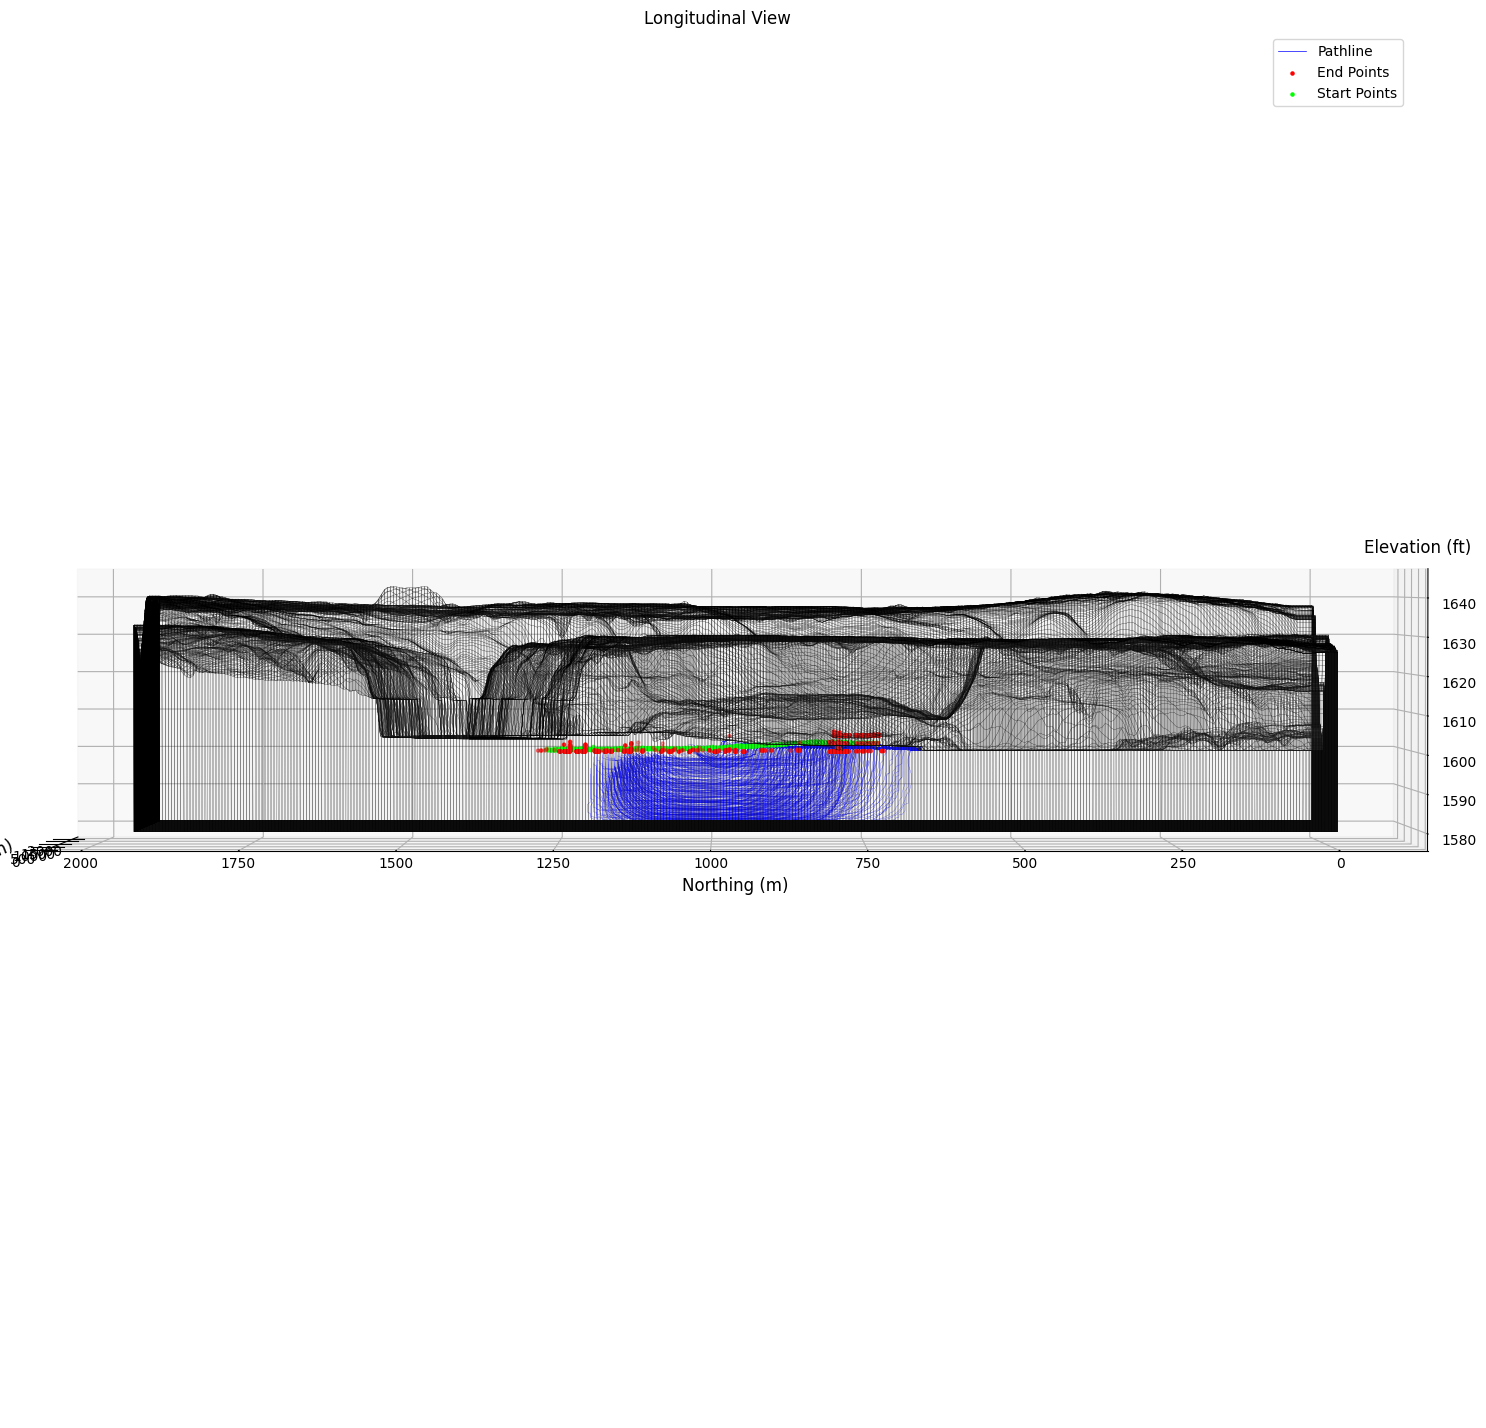

In [26]:
# Longitudinal View
# --- Plot the 3D cube ---
fig = plt.figure(figsize=(20, 18))
ax = fig.add_subplot(111, projection='3d')

zfac = 50.0  # Vertical exaggeration factor

top_scaled = top * zfac
botm_scaled = botm[-1] * zfac

# Top and bottom surfaces: white faces, black grid lines
surf_top = ax.plot_surface(
    X, Y, top,
    rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05, antialiased=True
)
surf_bot = ax.plot_surface(
    X, Y, botm[-1],
    rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05, antialiased=True
)

# Sides
y_side = y
x_side = x

# Left (x=0)
Z2 = np.column_stack([botm[-1, :, 0], top[:, 0]])  # shape (nrow, 2)
ax.plot_surface(
    np.zeros((nrow, 2)) + x[0], 
    np.repeat(y_side[:, None], 2, axis=1),
    Z2, rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05
)

# Right (x=max)
Z2 = np.column_stack([botm[-1, :, -1], top[:, -1]])
ax.plot_surface(
    np.full((nrow, 2), x[-1]), 
    np.repeat(y_side[:, None], 2, axis=1),
    Z2, rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05
)

# Front (y=0)
Z2 = np.column_stack([botm[-1, 0, :], top[0, :]])   # shape (ncol, 2)
ax.plot_surface(
    np.repeat(x_side[:, None], 2, axis=1),
    np.zeros((ncol, 2)) + y[0],
    Z2, rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05
)

# Back (y=max)
Z2 = np.column_stack([botm[-1, -1, :], top[-1, :]])
ax.plot_surface(
    np.repeat(x_side[:, None], 2, axis=1),
    np.full((ncol, 2), y[-1]),
    Z2, rstride=1, cstride=1,
    edgecolor='black', linewidth=0.1,
    color='white', alpha=0.05
)

# --- Highlight river cells with scatter in real coords ---
# river_x = []
# river_y = []
# river_z = []

# for cell in river_cells_df.itertuples(index=False):
#     k, j, i, stage = cell
#     if k == 0:
#         river_x.append(x[i])
#         river_y.append(y[j])
#         river_z.append(stage)

# ax.scatter(
#     river_x, river_y, river_z,
#     color='red', s=40, label='River Stage', zorder=10, depthshade=True
# )

# Flag to only label the first pathline
first_pathline = True

for particleid, group in part_sum.groupby('particleid'):
    group = group.sort_values('res_time')
    if first_pathline:
        ax.plot(
            group['m_xcoord'], group['m_ycoord'], group['zelev'],
            color='blue', linewidth=0.5, alpha=1.0, label='Pathline'
        )
        first_pathline = False
    else:
        ax.plot(
            group['m_xcoord'], group['m_ycoord'], group['zelev'],
            color='blue', linewidth=0.2, alpha=0.8
        )

ax.scatter(end_x, end_y, end_z, color='red', s=5, label='End Points', zorder = 2)
ax.scatter(start_x, start_y, start_z, color='lime', s=5, label='Start Points', zorder = 1)

# After plotting, set box aspect using actual range of coordinates
yfac = 8.0  # Vertical exaggeration factor for Y
Y_scaled = Y * yfac

xfac = 2.0
X_scaled = X * xfac

ax.set_box_aspect([
    X_scaled.max() - X_scaled.min(), 
    Y_scaled.max() - Y_scaled.min(), 
    top_scaled.max() - botm_scaled[-1].min()
])

#ax.legend(loc='upper left')
ax.set_xlabel('Easting (m)', labelpad=15, fontsize=12)
ax.set_ylabel('Northing (m)', labelpad=40, fontsize=12)

# After plotting everything
# After plotting everything
ax.set_zlabel('')  # Hide default

# Place custom label at the top of the z-axis, using your vertical exaggeration scale
x_pos = X.max() * 1.5                   
y_pos = Y.min()  - 200                 # Center of Y
z_pos = top.max() + 8  # Just above the max scaled elevation

# BUG FIX: Set z-axis label with custom position
ax.text(
    x_pos, y_pos, z_pos,
    'Elevation (ft)', fontsize=12, color='black',
    ha='center', va='bottom', rotation=0
)

plt.legend()
ax.set_title('Longitudinal View')
ax.view_init(elev=1, azim=180)  # adjust azim as needed for your domain orientation
plt.show()

(numpy.record, [('particleid', '<i4'), ('particlegroup', '<i4'), ('particleidloc', '<i4'), ('status', '<i4'), ('time0', '<f4'), ('time', '<f4'), ('node0', '<i4'), ('k0', '<i4'), ('xloc0', '<f4'), ('yloc0', '<f4'), ('zloc0', '<f4'), ('x0', '<f4'), ('y0', '<f4'), ('z0', '<f4'), ('zone0', '<i4'), ('initialcellface', '<i4'), ('node', '<i4'), ('k', '<i4'), ('xloc', '<f4'), ('yloc', '<f4'), ('zloc', '<f4'), ('x', '<f4'), ('y', '<f4'), ('z', '<f4'), ('zone', '<i4'), ('cellface', '<i4')])
All unique status codes (and counts): (array([5], dtype=int32), array([1255]))
Status codes: [5]
Min z: 1599.8125
Max z: 1605.0
Number of filtered particles: 1222


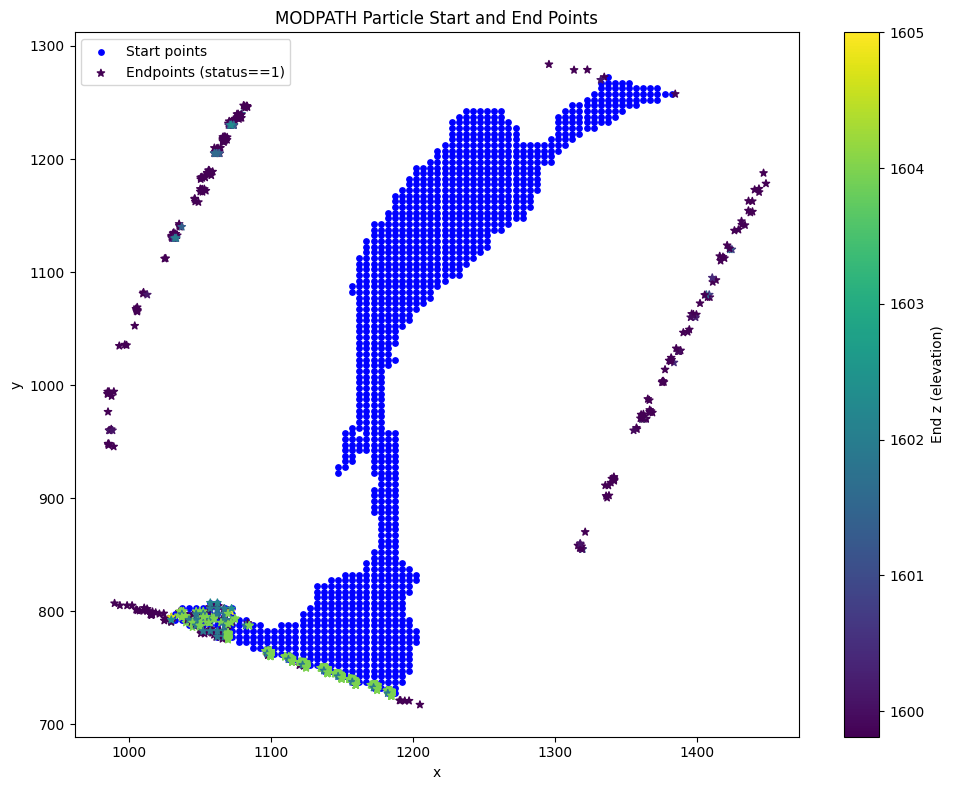

In [ ]:
workspace_mp7 = r"C:\Users\gtmen\Desktop\HyporheicFloPy\HP_workspace\mp7_workspace" #r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\mp7_workspace"

endpoint_file = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\mp7_workspace\Hyporheic_Project_mp_backward.mpend"

endpoint_reader = flopy.utils.EndpointFile(endpoint_file)
endpoints = endpoint_reader.get_alldata()

# Inspect the dtype to find the correct field
print(endpoints.dtype)
print("All unique status codes (and counts):", np.unique([ep['status'] for ep in endpoints], return_counts=True))
print("Status codes:", np.unique([ep['status'] for ep in endpoints]))

print("Min z:", np.min([ep['z'] for ep in endpoints]))
print("Max z:", np.max([ep['z'] for ep in endpoints]))

# Typical field: 'termination_code' or 'terminationtype' or 'terminationflag'
bed_elevation = 1599.8125  # Replace with the actual bed elevation value

filtered_particles = [
    ep for ep in endpoints
    if (
        (ep['z'] >= bed_elevation)
        and (ep['x'], ep['y']) != (ep['x0'], ep['y0'])
        and abs(ep['z'] - ep['z0']) > 0
       #and ep['status'] == 1   # <---- Only keep true endpoints!
    )
]

filtered_particle_ids = [int(ep['particleid']) for ep in filtered_particles]
print(f"Number of filtered particles: {len(filtered_particle_ids)}")

# --- Extract start and end coordinates ---
start_x = np.array([ep['x0'] for ep in endpoints])
start_y = np.array([ep['y0'] for ep in endpoints])
start_z = np.array([ep['z0'] for ep in endpoints])

end_x = np.array([ep['x'] for ep in endpoints])
end_y = np.array([ep['y'] for ep in endpoints])
end_z = np.array([ep['z'] for ep in endpoints])
status = np.array([ep['status'] for ep in endpoints])


In [22]:
import os
import numpy as np
import flopy

from flopy.utils import CellBudgetFile

# --- Load budget file ---
cbc_f = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\gwf_workspace\gwf_model.cbb"
cbc = CellBudgetFile(cbc_f)
print("Available budget record types:", cbc.get_unique_record_names())
budget_term = 'FLOW-JA-FACE'  # or 'CHD', depending on what you want to extract
arr = cbc.get_data(text=budget_term)[-1]
print("Budget array shape:", arr.shape)

nlay, nrow, ncol = arr.shape

# Get flow across cell faces (e.g., for calculating specific discharge)
flow_ja_face = cbc.get_data(text='FLOW-JA-FACE')[0]
print("FLOW-JA-FACE array shape:", flow_ja_face.shape)

endpoint_file = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\mp7_workspace\Hyporheic_Project_mp_forward.mpend"

bed_elevation = 1599.8125  # Replace with the actual bed elevation value
#delr = 5.0             # cell width (x) in model units
#delc = 5.0             # cell height (y) in model units

# ---- Read endpoint data ----
endpoint_reader = flopy.utils.EndpointFile(endpoint_file)
endpoints = endpoint_reader.get_alldata()

# --- Filtering endpoints ---
filtered_particles = [
    ep for ep in endpoints
    if (
        ep['z'] >= bed_elevation and
        (ep['x'], ep['y']) != (ep['x0'], ep['y0']) and
        abs(ep['z'] - ep['z0']) > 0
    )
]

#print(f"Filtered to {len(filtered_particles)} endpoints.")

def get_cell_flows(cbc_obj, k, j, i, terms):
    flows = {}
    for term in terms:
        arr = cbc_obj.get_data(text=term)[-1]
        flows[term.decode('utf-8').strip()] = arr[k, j, i]
    return flows

def in_bounds(k, j, i):
    return 0 <= k < nlay and 0 <= j < nrow and 0 <= i < ncol

print("First 5 filtered particle endpoint coordinates (start and end):")
for ep in filtered_particles[:5]:
    print(f"Start: (x0={ep['x0']}, y0={ep['y0']}, z0={ep['z0']}) | End: (x={ep['x']}, y={ep['y']}, z={ep['z']})")

# ---- Collect Unique Starting and Ending Cells ----
start_cells = set()
end_cells = set()

delr_mean = np.mean(delr)
delc_mean = np.mean(delc)

for ep in filtered_particles:
    k0 = int(ep['z0']) if 'z0' in ep.dtype.names else int(ep['k0'])
    j0 = int(ep['y0'] / delc_mean)
    i0 = int(ep['x0'] / delr_mean)
    k1 = int(ep['z']) if 'z' in ep.dtype.names else int(ep['k'])
    j1 = int(ep['y'] / delc_mean)
    i1 = int(ep['x'] / delr_mean)
    start_cells.add((k0, j0, i0))
    end_cells.add((k1, j1, i1))

# for ep in filtered_particles:
#     k0 = int(ep['z0']) if 'z0' in ep.dtype.names else int(ep['k0'])
#     j0 = int(ep['y0'])
#     i0 = int(ep['x0'] )
#     k1 = int(ep['z']) if 'z' in ep.dtype.names else int(ep['k'])
#     j1 = int(ep['y'])
#     i1 = int(ep['x'])
#     start_cells.add((k0, j0, i0))
#     end_cells.add((k1, j1, i1))

#print(f"Unique start cells: {len(start_cells)}")
#print(f"Unique end cells: {len(end_cells)}")

# ---- Print Cell Coordinates ----
for cell in start_cells:
    k, j, i = cell
    print(f"row={j}, col={i}")
    print(f"minimum x coordinate: {min({i for k, j, i in start_cells})}")
    print(f"maximum x coordinate: {max({i for k, j, i in start_cells})}")
    print(f"minimum y coordinate: {min({j for k, j, i in start_cells})}")
    print(f"maximum y coordinate: {max({j for k, j, i in start_cells})}")
    print(f"minimum z elevation (ft): {min({k for k, j, i in start_cells})}")
    print(f"maximum z elevation (ft): {max({k for k, j, i in start_cells})}")

nrow, ncol = top.shape
nlay = 40  # number of layers
z_value = 0.5 # ft, thickness for layers 2-40

# Initialize thickness array
layer_thicknesses = np.ones((nlay, nrow, ncol)) * z_value

# If layer 0 has a different thickness, set it here. 
# If layer 0 is also 0.5 ft, this is already correct.
# If you want layer 0 to have variable thickness, you need its bottom elevation array.

# Example: if you have array 'botm0' for layer 0 bottom:
layer_thicknesses[0, :, :] = top - bed_elevation

print("Layer thicknesses shape:", layer_thicknesses.shape)
print("Layer 0 thickness range:", layer_thicknesses[0, :, :].min(), "to", layer_thicknesses[0, :, :].max())
print("Other layers thickness (should be 0.5 ft):", np.unique(layer_thicknesses[1:, :, :]))

# find layer location of particles
layer_tops = np.zeros((nlay, nrow, ncol))
layer_bots = np.zeros((nlay, nrow, ncol))

layer_tops[0, :, :] = top
layer_bots[0, :, :] = top - layer_thicknesses[0, :, :]

for k in range(1, nlay):
    layer_tops[k, :, :] = layer_bots[k-1, :, :]
    layer_bots[k, :, :] = layer_tops[k, :, :] - layer_thicknesses[k, :, :]

print("Layer tops shape:", layer_tops.shape)
print("Layer bottoms shape:", layer_bots.shape)

# --- Function to get layer index for a cell ---
def get_layer_from_z(z, row, col, layer_tops, layer_bots):
    nlay = layer_tops.shape[0]
    for k in range(nlay):
        top_elev = layer_tops[k, row, col]
        bot_elev = layer_bots[k, row, col]
        if bot_elev <= z < top_elev:
            return k
    return None

# --- Assign layers for each start cell ---
start_cells_zone = [
    {
        'layer': get_layer_from_z(z, row, col, layer_tops, layer_bots),
        'row': row,
        'col': col,
        'z': z
    }
    for z, row, col in start_cells
    if get_layer_from_z(z, row, col, layer_tops, layer_bots) is not None
]

# --- Assign layers for each end cell ---
end_cells_zone = [
    {
        'layer': get_layer_from_z(z, row, col, layer_tops, layer_bots),
        'row': row,
        'col': col,
        'z': z
    }
    for z, row, col in end_cells
    if get_layer_from_z(z, row, col, layer_tops, layer_bots) is not None
]

# --- Convert to DataFrames ---
start_cells_df = pd.DataFrame(start_cells_zone)
end_cells_df = pd.DataFrame(end_cells_zone)

print("First 5 start cells with layer info:")
print(start_cells_df.head())

print("First 5 end cells with layer info:")
print(end_cells_df.head())


Available budget record types: [np.bytes_(b'    FLOW-JA-FACE'), np.bytes_(b'      DATA-SPDIS'), np.bytes_(b'        DATA-SAT'), np.bytes_(b'             CHD')]
Budget array shape: (1, 1, 2191822)
FLOW-JA-FACE array shape: (1, 1, 2191822)
First 5 filtered particle endpoint coordinates (start and end):
Start: (x0=1332.5, y0=1267.5, z0=1600.3125) | End: (x=1337.3253173828125, y=1270.0, z=1600.28125)
Start: (x0=1337.5, y0=1267.5, z0=1600.0) | End: (x=1338.1483154296875, y=1270.0, z=1600.28125)
Start: (x0=1342.5, y0=1267.5, z0=1599.84375) | End: (x=1350.0, y=1269.5836181640625, z=1599.875)
Start: (x0=1347.5, y0=1267.5, z0=1599.84375) | End: (x=1350.0, y=1268.5545654296875, z=1599.875)
Start: (x0=1332.5, y0=1262.5, z0=1600.125) | End: (x=1337.3253173828125, y=1270.0, z=1600.28125)
row=166, col=235
minimum x coordinate: 206
maximum x coordinate: 275
minimum y coordinate: 145
maximum y coordinate: 253
minimum z elevation (ft): 1599
maximum z elevation (ft): 1602
row=163, col=229
minimum x coor

In [23]:
# --- Zone Array Initialization ---
nlay, nrow, ncol = gwf.modelgrid.nlay, gwf.modelgrid.nrow, gwf.modelgrid.ncol
zone_array = np.zeros((nlay, nrow, ncol), dtype=int)
print(type(gwf.modelgrid))
ncpl = gwf.modelgrid.ncpl
print("Number of cells per layer (ncpl):", ncpl)

# --- Load flow data ---
flow_ja_face = cbc.get_data(kstpkper=(0, 0), text='FLOW-JA-FACE', full3D=True)[0] # is this the top cell face, and last time step?
print(flow_ja_face.shape)

# --- Get global cell indices ---
start_flows = []
for cell in start_cells_zone:
    k, j, i = cell['layer'], cell['row'], cell['col']
    icell = gwf.modelgrid.get_node((k, j, i))
    start_flows.append(flow_ja_face[0, 0, icell])
start_flows = np.array(start_flows)

end_flows = []
for cell in end_cells_zone:
    k, j, i = cell['layer'], cell['row'], cell['col']
    icell = gwf.modelgrid.get_node((k, j, i))
    end_flows.append(flow_ja_face[0, 0, icell])
end_flows = np.array(end_flows)

print("Start flows shape:", start_flows.shape)
print("Start flows first 5 values:", start_flows[:5])
print("End flows shape:", end_flows.shape)
print("End flows first 5 values:", end_flows[:5])

# --- Calculate flow differences ---
total_start_flow = np.sum(start_flows)
total_end_flow = np.sum(end_flows)
print(f"Total start flow: {total_start_flow}")
print(f"Total end flow: {total_end_flow}")

hyporheic_flow_rate_ft3_d = abs(total_start_flow) + total_end_flow
print(f"Hyporheic flow rate (ft³/d): {hyporheic_flow_rate_ft3_d}")

average_hyporheic_flow_rate_ft3_d = (total_start_flow + total_end_flow) / 2
print(f"Average hyporheic flow rate (ft³/d): {average_hyporheic_flow_rate_ft3_d}")


<class 'flopy.discretization.structuredgrid.StructuredGrid'>
Number of cells per layer (ncpl): 165935
(1, 1, 2191822)
Start flows shape: (1207, 1)
Start flows first 5 values: [[-0.13636698]
 [ 0.02513183]
 [-0.00803819]
 [ 0.10707489]
 [-0.01737048]]
End flows shape: (28, 1)
End flows first 5 values: [[ 8.97830432e-07]
 [ 3.93956725e-07]
 [-3.24281359e-06]
 [ 8.52597782e-04]
 [-3.75145540e-03]]
Total start flow: -0.8007924045719745
Total end flow: -0.5307783814464528
Hyporheic flow rate (ft³/d): 0.2700140231255217
Average hyporheic flow rate (ft³/d): -0.6657853930092137


In [24]:
import pandas as pd

def parse_stats_file(filepath):
    results = []
    group = None

    with open(filepath, 'r') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        # New group header: not a stat, not empty, not a value line, not indented, not a summary
        is_group_header = (
            line and
            not line.startswith(('mean:', 'median:', 'min:', 'max:', 'range:')) and
            ':' not in line and
            not line.startswith('(')
        )
        # Group headers can also be "Per Cell: ..." or "Particle Path: ..."
        is_special_group = line.startswith(('Per Cell:', 'Particle Path:'))

        if is_group_header or is_special_group:
            group = line
        elif group and ':' in line:
            # Key-value pair (stat line or summary line)
            stat, val = line.split(':', 1)
            stat = stat.strip()
            try:
                value = float(val.strip())
            except ValueError:
                value = val.strip()
            results.append({'Group': group, 'Stat': stat, 'Value': value})

    df = pd.DataFrame(results)
    return df

if __name__ == "__main__":
    file_path = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\Hyporheic_output\pathline_stats.txt"  # <-- change this to your filename
    df_stats = parse_stats_file(file_path)
    #print(df_stats.to_string(index=False))
    # Uncomment to save as CSV:
    df_stats.to_csv("Model_Workflow_Summary.csv", index=False)

def publication_ready_table(df, float_format="{:,.3f}"):
    # Sort by Group to ensure grouping
    df = df.copy()
    df['Group'] = df['Group'].str.strip()
    df['Stat'] = df['Stat'].str.strip()
    # Optionally, you can order the stats
    stat_order = ["mean", "median", "min", "max", "range"]
    # For summaries with custom stats, you may want to preserve their order

    lines = []
    prev_group = None
    for idx, row in df.iterrows():
        group, stat, value = row['Group'], row['Stat'], row['Value']
        # Format value nicely
        if isinstance(value, float):
            # Use scientific if it's very large/small, else fixed-point
            if abs(value) > 1e5 or (abs(value) < 1e-3 and value != 0):
                value_fmt = f"{value:.3e}"
            else:
                value_fmt = float_format.format(value)
        else:
            value_fmt = str(value)
        # Print group header only once
        if group != prev_group:
            lines.append(f"\n**{group}**")
            prev_group = group
        # Indent stat names
        lines.append(f"  - {stat}: {value_fmt}")
    # Combine into one markdown string
    return "\n".join(lines)

# Example usage:
print(publication_ready_table(df_stats))


**Linear Path Length (y-range, ft)**
  - mean: 246.340
  - median: 177.500
  - min: 2.500
  - max: 544.610
  - range: 542.110

**Path Width (x-range, ft)**
  - mean: 148.510
  - median: 158.440
  - min: 1.450
  - max: 351.160
  - range: 349.710

**Path Depth (z-range, ft)**
  - mean: 5.840
  - median: 1.310
  - min: 0.030
  - max: 21.560
  - range: 21.530

**Net Path Length (ft)**
  - mean: 326.760
  - median: 261.280
  - min: 15.600
  - max: 692.360
  - range: 676.760

**Zone Budget Summary**
  - Total number of start cells: 1,233.000
  - Total start flow: -2.192
  - Total number of end cells: 28.000
  - Total end flow: -0.531
  - Average Hyporheic flow rate (ft³/d): -1.361
  - Hyporheic flow rate (ft³/d): 1.661

**Per Cell: Total Volume Available (ft³)**
  - mean: 501.595
  - median: 487.500
  - min: 487.500
  - max: 611.163
  - range: 123.663

**Per Cell: Total Hyporheic Volume (ft³)**
  - mean: 41.264
  - median: 0.000
  - min: 0.000
  - max: 12,489.996
  - range: 12,489.996

**Pe